In [41]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages



In [42]:
class State(TypedDict):
    messages:Annotated[list,add_messages]
    
     

In [43]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [44]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="llama3-8b-8192")


In [45]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 8192, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F8DE751B10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F8DE847350>, model_name='llama3-8b-8192', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [46]:
llm = init_chat_model("groq:llama-3.3-70b-versatile")

In [47]:
llm

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F8DE750C10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F8DE76BB90>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [48]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [49]:
graph_builder= StateGraph(State)

graph_builder.add_node("llmchatbot",chatbot)

graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

graph=graph_builder.compile()

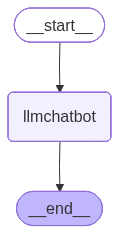

In [50]:
graph

In [51]:
response = graph.invoke({"messages":"hi"})

In [52]:
response["messages"][-1].content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [53]:
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)

Hello. I'm doing well, thanks for asking. I'm a large language model, so I don't have feelings or emotions like humans do, but I'm here and ready to help with any questions or topics you'd like to discuss. How about you? How's your day going so far?


In [69]:
from time import time
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2,time_range="week")
tool.invoke("what is langgraph")

"No search results found for 'what is langgraph'. Suggestions: Try a general search using 'general' topic. Try modifying your search parameters with one of these approaches."

In [70]:
def multiply(a:int,b:int)->int:
    """multiply a and b

    Args:
        a:first int
        b:second int

    Returns:
        int:output int
    """
    return a*b
    

In [71]:
tools=[tool,multiply]

In [72]:
llm_with_tool=llm.bind_tools(tools)

In [73]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001F8DE750C10>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001F8DE76BB90>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and trusted results. Useful for when you need to answer questions about current events. It not only retrieves URLs and snippets, but offers advanced search depths, domain management, time range filters, and image search, this tool del

In [74]:
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state:State):
    return{"messages":[llm_with_tool.invoke(state["messages"])]}

builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges("tool_calling_llm",tools_condition)

builder.add_edge("tools",END)

graph= builder.compile()




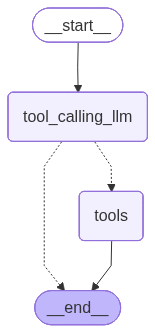

In [75]:
graph

In [76]:
response=graph.invoke({"messages":"what is the recent ai news"})

In [77]:
response

{'messages': [HumanMessage(content='what is the recent ai news', additional_kwargs={}, response_metadata={}, id='ef47d00d-dbc1-4194-bbc7-a0da68b00cc0'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'j8fm35m4z', 'function': {'arguments': '{"query":"recent AI news","search_depth":"advanced","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 1751, 'total_tokens': 1789, 'completion_time': 0.101741248, 'completion_tokens_details': None, 'prompt_time': 0.299564828, 'prompt_tokens_details': None, 'queue_time': 0.162394359, 'total_time': 0.401306076}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_45180df409', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e5e0c-4dbb-78c0-8c56-c756075db043-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'recent AI news', 'searc

In [78]:
response["messages"][-1].content

'{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/openai-posts-job-to-prepare-for-self-training-ai-8d180686", "title": "OpenAI posts job to prepare for self-training AI - Let\'s Data Science", "score": 0.6601948, "published_date": "Sat, 23 May 2026 09:06:58 GMT", "content": "## Scoring Rationale\\n\\nThe story is a notable signal about industry attention to advanced safety concerns and hiring; it affects practitioners via talent markets and research priorities but does not by itself change technical capabilities.\\n\\nMoreOpenAI news→\\n\\nPractice interview problems based on real data\\n\\n1,500+ SQL & Python problems across 15 industry datasets — the exact type of data you work with.\\n\\nTry 250 free problems\\n\\n## More AI & Data Science News\\n\\n6.2\\n\\nMay 23\\n\\n### Meta Launch Crashes Reddit Stock Suddenly6.9\\n\\nMay 23\\n\\n### Startups Adopt Claude Code as Default Coding Tool6.2\\

In [79]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (j8fm35m4z)
 Call ID: j8fm35m4z
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://letsdatascience.com/news/openai-posts-job-to-prepare-for-self-training-ai-8d180686", "title": "OpenAI posts job to prepare for self-training AI - Let's Data Science", "score": 0.6601948, "published_date": "Sat, 23 May 2026 09:06:58 GMT", "content": "## Scoring Rationale\n\nThe story is a notable signal about industry attention to advanced safety concerns and hiring; it affects practitioners via talent markets and research prioritie

In [80]:
response=graph.invoke({"messages":"what is 5 multiplied by 7"})

for m in response['messages']:
    m.pretty_print()


================================ Human Message =================================

what is 5 multiplied by 7
================================== Ai Message ==================================
Tool Calls:
  multiply (dmn24z7wt)
 Call ID: dmn24z7wt
  Args:
    a: 5
    b: 7
================================= Tool Message =================================
Name: multiply

35


In [81]:
response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (whagnyped)
 Call ID: whagnyped
  Args:
    query: recent ai news
    time_range: day
    topic: news
  multiply (c793fm6y3)
 Call ID: c793fm6y3
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

{"query": "recent ai news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cbsnews.com/news/ai-backlash-college-commencements-2026/", "title": "Recent commencement speeches show students are souring on AI. How deep is the angst? - CBS News", "score": 0.7211353, "published_date": "Tue, 19 May 2026 21:19:31 GMT", "content": "She previously worked at \"60 Minutes,\" CBSNews.com and CBS News 24/7 as part of the CBS News Associate Program